<a href="https://colab.research.google.com/github/rokhmaunnisa/Speech-Emotion-Detection/blob/main/lstm_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#Shell 1
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
!pip install kaggle

In [10]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rokhmaunnisa","key":"cee3e2a2130ec31b92f90b2ffd19224d"}'}

In [12]:
!mkdir -p ~/.kaggle  #kaggle directory
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [13]:
#list down \ kaggle datasets
!kaggle datasets list

ref                                                          title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                            Impact of Ai on Students                       1187170  2026-05-10 23:12:10.070000           7597        198                1  
datasnaek/youtube-new                                        Trending YouTube Video Statistics            210575746  2019-06-03 00:56:47.177000         306152       5934        0.7941176  
nolanbconaway/pitchfork-data                                 18,393 Pitchfork Reviews                      34891456  2017-01-13 04:18:10.113000          18022        459        0.7058824  
rtatman/188-million-us-wildfires                       

In [16]:
!kaggle datasets list -s 'ravdess'

ref                                                           title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
uwrfkaggler/ravdess-emotional-speech-audio                    RAVDESS Emotional speech audio                        450102890  2019-01-19 18:28:31.433000         109094        729  0.875            
uwrfkaggler/ravdess-emotional-song-audio                      RAVDESS Emotional song audio                          477641670  2019-01-19 21:01:49.663000           3592         52  0.875            
orvile/ravdess-dataset                                        Audio-Visual Database (RAVDESS)                     25615024242  2025-04-19 20:46:40.283000           3121         34  1                
karti

In [20]:
!kaggle datasets download -d 'uwrfkaggler/ravdess-emotional-speech-audio' \
-p /data/kaggleDataSetForSpeechRecgnition

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
ravdess-emotional-speech-audio.zip: Skipping, found more recently modified local copy (use --force to force download)


In [35]:
# Unzip the downloaded dataset
import zipfile
import os

zip_path = '/data/kaggleDataSetForSpeechRecgnition/ravdess-emotional-speech-audio.zip'
extract_dir = '/data/kaggleDataSetForSpeechRecgnition/ravdess-emotional-speech-audio-extracted'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Dataset extracted to: {extract_dir}")

Dataset extracted to: /data/kaggleDataSetForSpeechRecgnition/ravdess-emotional-speech-audio-extracted


In [23]:
#shell 2
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
#shell 3

dataset_path = "/data/kaggleDataSetForSpeechRecgnition/ravdess-emotional-speech-audio-extracted" # Updated path

paths = []
emotions = []

emotion_dict = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            # Ensure the file name is correctly parsed to get emotion
            # Example: 03-01-01-01-01-01-01.wav -> emotion_dict['01']
            parts = file.split("-")
            if len(parts) > 2 and parts[2] in emotion_dict:
                emotion = emotion_dict[parts[2]]
                path = os.path.join(root, file)

                paths.append(path)
                emotions.append(emotion)
            else:
                print(f"Skipping file {file}: Could not extract emotion.")

df = pd.DataFrame()
df["path"] = paths
df["emotion"] = emotions

df.head()

,path,emotion
0,/data/kaggleDataSetForSpeechRecgnition/ravdess...,neutral
1,/data/kaggleDataSetForSpeechRecgnition/ravdess...,angry
2,/data/kaggleDataSetForSpeechRecgnition/ravdess...,happy
3,/data/kaggleDataSetForSpeechRecgnition/ravdess...,angry
4,/data/kaggleDataSetForSpeechRecgnition/ravdess...,happy


In [29]:
!ls -lR /data/kaggleDataSetForSpeechRecgnition/ravdess-emotional-speech-audio-extracted

/data/kaggleDataSetForSpeechRecgnition/ravdess-emotional-speech-audio-extracted:
total 100
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_01
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_02
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_03
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_04
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_05
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_06
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_07
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_08
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_09
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_10
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_11
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_12
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_13
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_14
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_15
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_16
drwxr-xr-x  2 root root 4096 Jun  7 13:35 Actor_17
drwxr-xr-x  2 root root 4096 Jun  7 13:35 

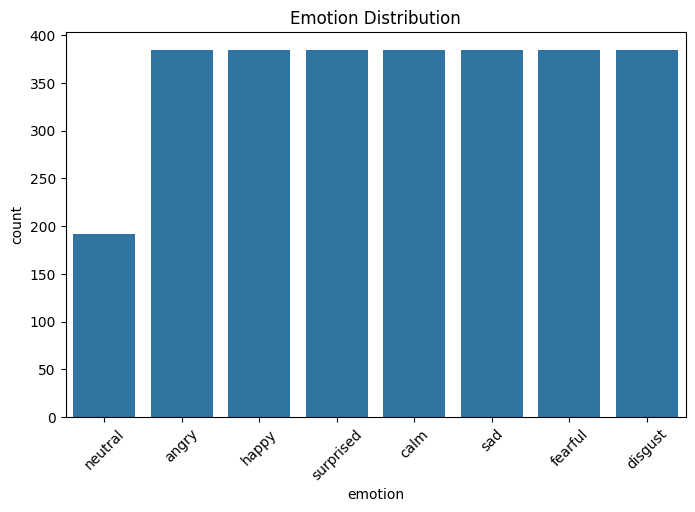

In [26]:
#shell 4

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

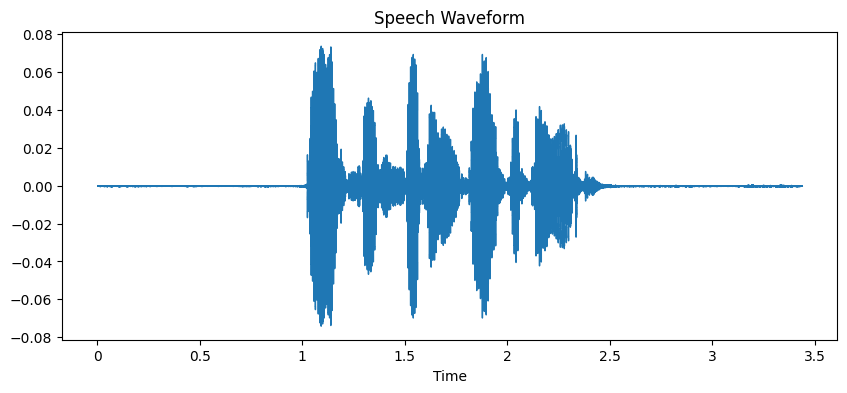

In [28]:
if not df.empty:
    sample_path = df.path.iloc[0]
    signal, sr = librosa.load(sample_path)

    plt.figure(figsize=(10,4))
    librosa.display.waveshow(signal, sr=sr)
    plt.title("Speech Waveform")
    plt.show()
else:
    print("DataFrame 'df' is empty. Cannot plot waveform.")

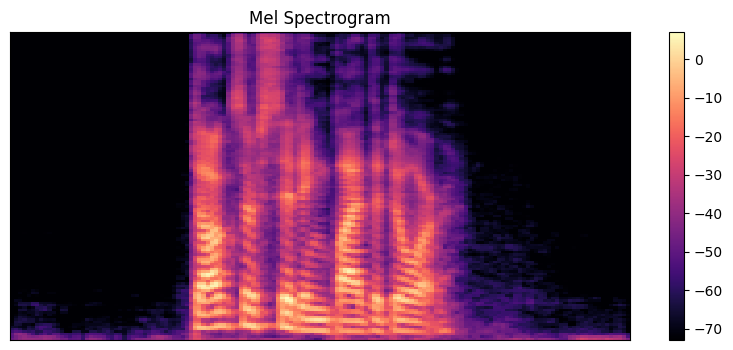

In [31]:
#shell 6

spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.power_to_db(spectrogram))
plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

In [36]:
#shell 7
def extract_features(file_path):

    signal, sr = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)

    return np.mean(mfcc.T, axis=0)

In [37]:
#shell 8

X = []
y = []

for path, emotion in zip(df.path, df.emotion):

    features = extract_features(path)

    X.append(features)
    y.append(emotion)

X = np.array(X)
y = np.array(y)

In [34]:
#shell 9
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [38]:
#shell 10
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
#shell 11
X_train = torch.tensor(X_train).float()
X_test = torch.tensor(X_test).float()

# Ensure y_train and y_test are numerical before converting to torch.tensor
# The previous LabelEncoder step should have handled this, but if they are still string arrays,
# we re-transform them here using the globally available 'encoder' object.
if isinstance(y_train, np.ndarray) and (y_train.dtype == object or y_train.dtype.kind == 'U'):
    y_train = encoder.transform(y_train)
    y_test = encoder.transform(y_test)

y_train = torch.tensor(y_train).long()
y_test = torch.tensor(y_test).long()

/tmp/ipykernel_543/1730748782.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train).float()
/tmp/ipykernel_543/1730748782.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test).float()


In [43]:
#shell 12
class EmotionLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):

        super(EmotionLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        output, (hn, cn) = self.lstm(x)

        out = self.fc(hn[-1])

        return out

In [44]:
#shell 13
input_size = X_train.shape[1]
hidden_size = 128
num_classes = len(np.unique(y))

model = EmotionLSTM(input_size, hidden_size, num_classes)

In [45]:
#shell 14
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [46]:
#shell 15

epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 30
counter = 0

for epoch in range(epochs):

    # ======================
    # TRAINING
    # ======================
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Training accuracy
    _, predicted = torch.max(outputs, 1)
    train_acc = (predicted == y_train).sum().item() / y_train.size(0)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    with torch.no_grad():

        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)

        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = (val_predicted == y_test).sum().item() / y_test.size(0)

    # ======================
    # STORE VALUES
    # ======================
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ======================
    # EARLY STOPPING
    # ======================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_lstm_ser_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

    # ======================
    # PRINT PROGRESS
    # ======================
    if (epoch+1) % 10 == 0 or epoch == 0:

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")
        print("--------------------------------------------------")

Epoch [1/100]
Train Loss: 2.1022 | Train Acc: 0.1215
Val   Loss: 2.0945 | Val   Acc: 0.1424
--------------------------------------------------
Epoch [10/100]
Train Loss: 2.0236 | Train Acc: 0.2062
Val   Loss: 2.0311 | Val   Acc: 0.2188
--------------------------------------------------
Epoch [20/100]
Train Loss: 1.9723 | Train Acc: 0.2839
Val   Loss: 1.9814 | Val   Acc: 0.2760
--------------------------------------------------
Epoch [30/100]
Train Loss: 1.9202 | Train Acc: 0.3121
Val   Loss: 1.9359 | Val   Acc: 0.2708
--------------------------------------------------
Epoch [40/100]
Train Loss: 1.8650 | Train Acc: 0.3299
Val   Loss: 1.8856 | Val   Acc: 0.3021
--------------------------------------------------
Epoch [50/100]
Train Loss: 1.8076 | Train Acc: 0.3411
Val   Loss: 1.8389 | Val   Acc: 0.3333
--------------------------------------------------
Epoch [60/100]
Train Loss: 1.7510 | Train Acc: 0.3746
Val   Loss: 1.7986 | Val   Acc: 0.3576
--------------------------------------------

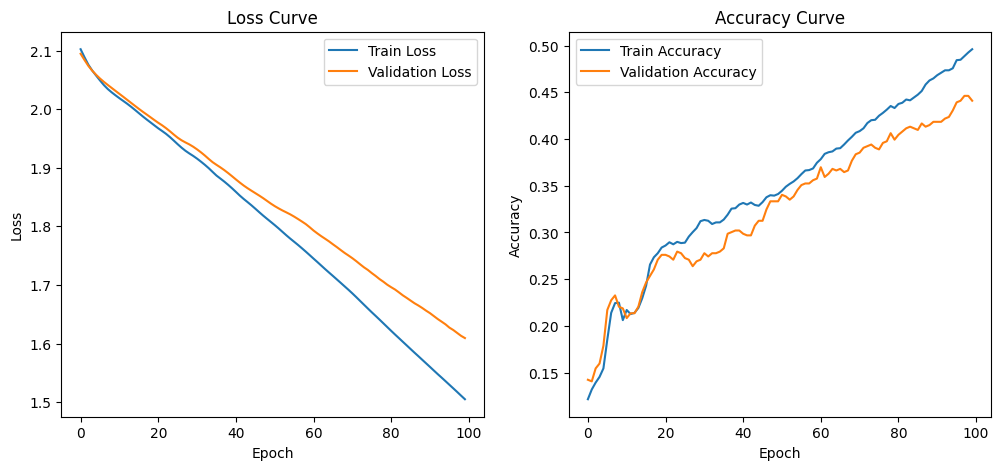

In [47]:
#shell 16
plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [48]:
#shell 17
with torch.no_grad():

    predictions = model(X_test)

    predicted = torch.argmax(predictions, axis=1)

In [49]:
#shell 18
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.59      0.62      0.60        76
           1       0.39      0.75      0.51        87
           2       0.47      0.37      0.41        78
           3       0.51      0.42      0.46        79
           4       0.51      0.33      0.40        67
           5       0.00      0.00      0.00        37
           6       0.34      0.22      0.26        88
           7       0.38      0.61      0.47        64

    accuracy                           0.44       576
   macro avg       0.40      0.41      0.39       576
weighted avg       0.42      0.44      0.41       576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


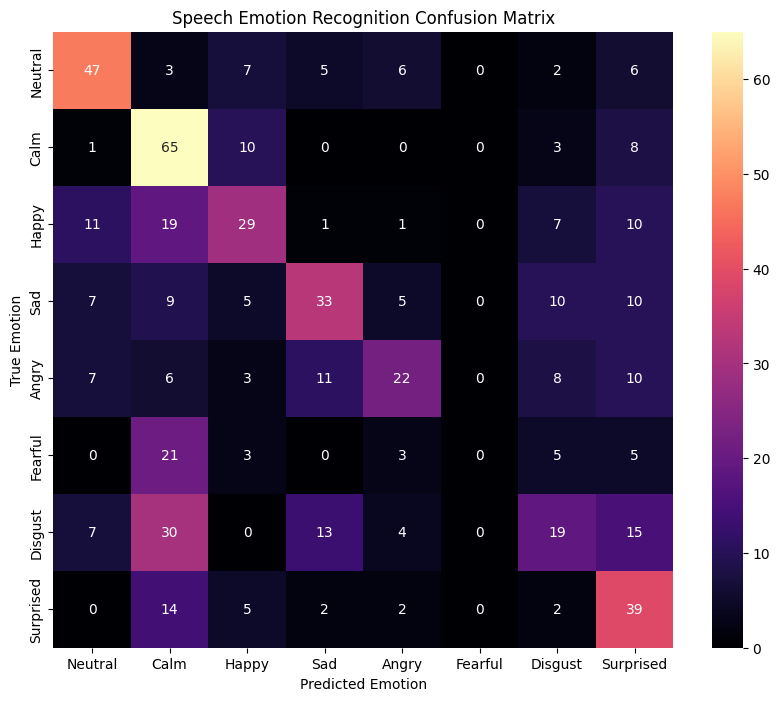

In [50]:
#shell 19
# Create confusion matrix
cm = confusion_matrix(y_test, predicted)

labels = ['Neutral','Calm','Happy','Sad','Angry','Fearful','Disgust','Surprised']

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='magma')

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Speech Emotion Recognition Confusion Matrix")

plt.show()

In [51]:
#shell 20
class EmotionBiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(EmotionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        output, (hn, cn) = self.lstm(x)

        out = self.fc(output[:, -1, :])

        return out

In [52]:
#shell 21
input_size = X_train.shape[1]
hidden_size = 128
num_classes = len(np.unique(y))

model_bilstm = EmotionBiLSTM(input_size, hidden_size, num_classes)

In [53]:
#shell 22
class CNN_BiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(CNN_BiLSTM, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.permute(0,2,1)

        output, _ = self.lstm(x)

        out = self.fc(output[:, -1, :])

        return out

In [54]:
#shell 23
model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)

In [55]:
#shell 24
def train_model(model, model_name, X_train, y_train, X_test, y_test,
                criterion, optimizer, epochs=100, patience=30):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):

        # ======================
        # TRAINING
        # ======================
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Training accuracy
        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train).sum().item() / y_train.size(0)

        # ======================
        # VALIDATION
        # ======================
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test)

            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = (val_predicted == y_test).sum().item() / y_test.size(0)

        # ======================
        # STORE VALUES
        # ======================
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ======================
        # EARLY STOPPING
        # ======================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            counter = 0

            torch.save(model.state_dict(), f"best_{model_name}.pth")

        else:
            counter += 1

        if counter >= patience:

            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # ======================
        # PRINT PROGRESS
        # ======================
        if (epoch+1) % 10 == 0 or epoch == 0:

            print(f"{model_name} Epoch [{epoch+1}/{epochs}]")

            print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")

            print("--------------------------------------------------")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [56]:
#shell 24
model_bilstm = EmotionBiLSTM(input_size, 128, num_classes)

optimizer_bilstm = torch.optim.Adam(model_bilstm.parameters(), lr=0.01)

train_losses_bi, val_losses_bi, train_acc_bi, val_acc_bi = train_model(
    model_bilstm,
    "bilstm",
    X_train, y_train,
    X_test, y_test,
    criterion,
    optimizer_bilstm
)

bilstm Epoch [1/100]
Train Loss: 2.0785 | Train Acc: 0.1211
Val   Loss: 2.0826 | Val   Acc: 0.1736
--------------------------------------------------
bilstm Epoch [10/100]
Train Loss: 1.8365 | Train Acc: 0.2899
Val   Loss: 1.8728 | Val   Acc: 0.2986
--------------------------------------------------
bilstm Epoch [20/100]
Train Loss: 1.5523 | Train Acc: 0.4253
Val   Loss: 1.6780 | Val   Acc: 0.3802
--------------------------------------------------
bilstm Epoch [30/100]
Train Loss: 1.4510 | Train Acc: 0.4405
Val   Loss: 1.5071 | Val   Acc: 0.4306
--------------------------------------------------
bilstm Epoch [40/100]
Train Loss: 1.1415 | Train Acc: 0.5825
Val   Loss: 1.3375 | Val   Acc: 0.5069
--------------------------------------------------
bilstm Epoch [50/100]
Train Loss: 0.9188 | Train Acc: 0.6806
Val   Loss: 1.2450 | Val   Acc: 0.5399
--------------------------------------------------
bilstm Epoch [60/100]
Train Loss: 0.8299 | Train Acc: 0.6710
Val   Loss: 1.1690 | Val   Acc: 0.

In [57]:
#shell 25
model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)

optimizer_cnn = torch.optim.Adam(model_cnnbilstm.parameters(), lr=0.004)

train_losses_cnn, val_losses_cnn, train_acc_cnn, val_acc_cnn = train_model(
    model_cnnbilstm,
    "cnnbilstm",
    X_train, y_train,
    X_test, y_test,
    criterion,
    optimizer_cnn
)

cnnbilstm Epoch [1/100]
Train Loss: 2.0845 | Train Acc: 0.0673
Val   Loss: 2.0497 | Val   Acc: 0.1788
--------------------------------------------------
cnnbilstm Epoch [10/100]
Train Loss: 1.8948 | Train Acc: 0.2730
Val   Loss: 1.9397 | Val   Acc: 0.2326
--------------------------------------------------
cnnbilstm Epoch [20/100]
Train Loss: 1.7085 | Train Acc: 0.3416
Val   Loss: 1.8444 | Val   Acc: 0.2778
--------------------------------------------------
cnnbilstm Epoch [30/100]
Train Loss: 1.5919 | Train Acc: 0.3993
Val   Loss: 1.7615 | Val   Acc: 0.3490
--------------------------------------------------
cnnbilstm Epoch [40/100]
Train Loss: 1.4491 | Train Acc: 0.4570
Val   Loss: 1.6373 | Val   Acc: 0.4010
--------------------------------------------------
cnnbilstm Epoch [50/100]
Train Loss: 1.1804 | Train Acc: 0.5907
Val   Loss: 1.4840 | Val   Acc: 0.4497
--------------------------------------------------
cnnbilstm Epoch [60/100]
Train Loss: 1.0472 | Train Acc: 0.6285
Val   Loss: 1

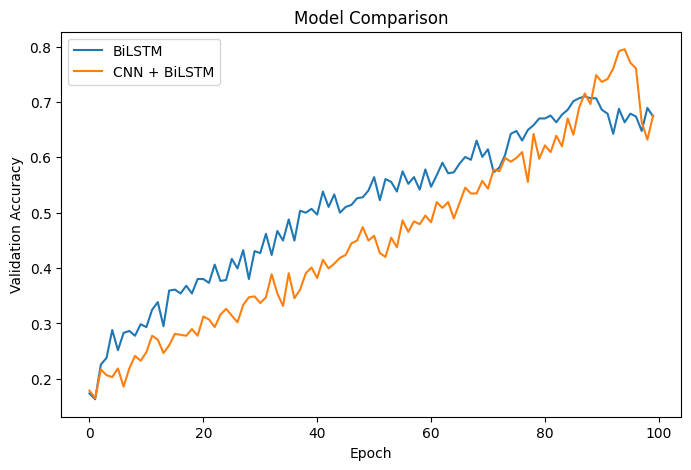

In [58]:
#shell 26

plt.figure(figsize=(8,5))

plt.plot(val_acc_bi, label="BiLSTM")
plt.plot(val_acc_cnn, label="CNN + BiLSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")

plt.legend()

plt.show()

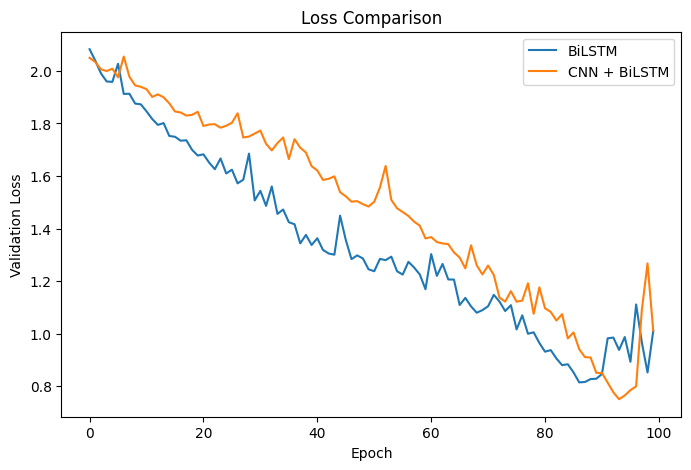

In [59]:
#shell 27
plt.figure(figsize=(8,5))

plt.plot(val_losses_bi, label="BiLSTM")
plt.plot(val_losses_cnn, label="CNN + BiLSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison")

plt.legend()

plt.show()

In [60]:
#shell 28
# BiLSTM Predictions
model_bilstm.eval()

with torch.no_grad():
    outputs_bi = model_bilstm(X_test)
    _, preds_bi = torch.max(outputs_bi, 1)


# CNN + BiLSTM Predictions
model_cnnbilstm.eval()

with torch.no_grad():
    outputs_cnn = model_cnnbilstm(X_test)
    _, preds_cnn = torch.max(outputs_cnn, 1)

In [61]:
#shell 29
from sklearn.metrics import confusion_matrix

cm_bi = confusion_matrix(y_test, preds_bi)
cm_cnn = confusion_matrix(y_test, preds_cnn)

In [62]:
#shell 30
emotion_labels = [
    "Neutral",
    "Calm",
    "Happy",
    "Sad",
    "Angry",
    "Fearful",
    "Disgust",
    "Surprised"
]

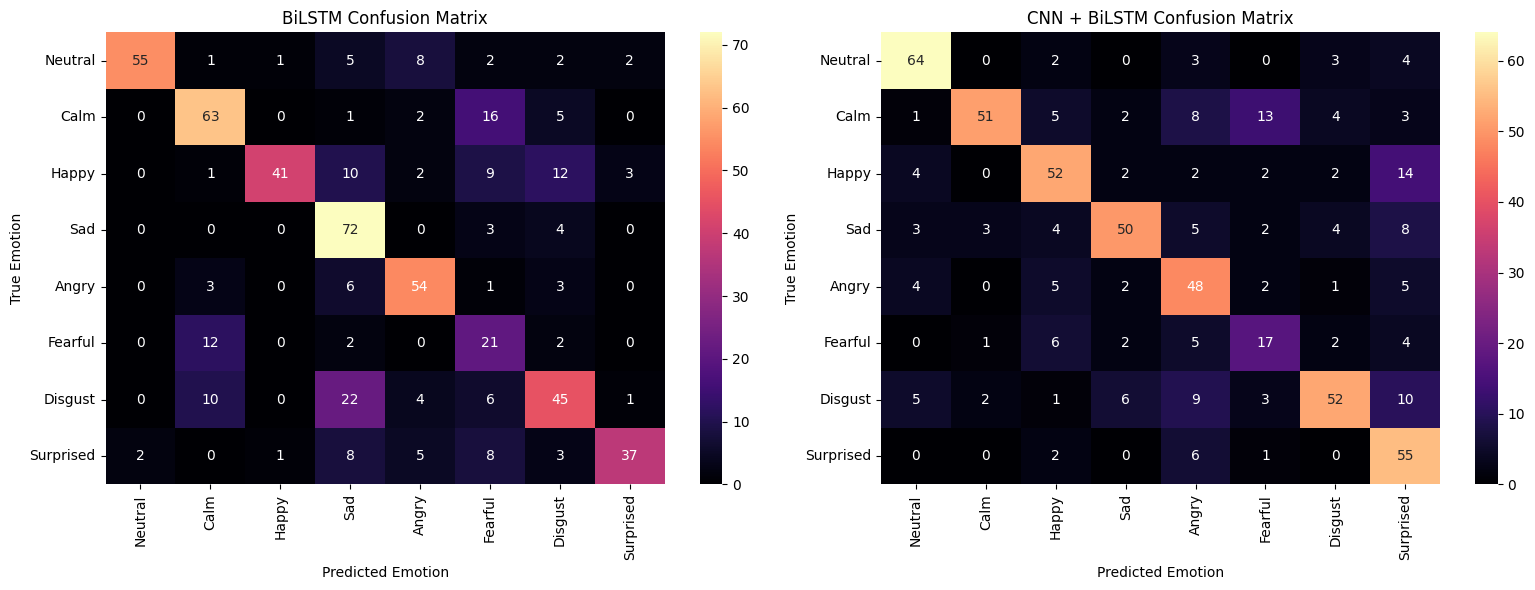

In [63]:
#shell 31
plt.figure(figsize=(16,6))

# BiLSTM Heatmap
plt.subplot(1,2,1)

sns.heatmap(cm_bi,
            annot=True,
            fmt="d",
            cmap="magma",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")


# CNN + BiLSTM Heatmap
plt.subplot(1,2,2)

sns.heatmap(cm_cnn,
            annot=True,
            fmt="d",
            cmap="magma",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("CNN + BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")

plt.tight_layout()
plt.show()